<a href="https://colab.research.google.com/github/hiroko-tsuchida/git-github-test/blob/main/notebook_house_XGBR_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import math

#標準化
#from sklearn.preprocessing import StandardScaler
# データ分割・交差検証用
from sklearn.model_selection import train_test_split, KFold
# 回帰モデルの評価指標（平均二乗誤差）
from sklearn.metrics import mean_squared_error

# 勾配ブースティングモデル（高精度でよく使う）
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

# 警告を制御するライブラリ
import warnings
# 不要な警告メッセージを非表示にする
warnings.filterwarnings("ignore")

In [35]:
from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('ctrain.csv')
df_train.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [36]:
df_test = pd.read_csv("/content/drive/MyDrive/house/test.csv")
df_test.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal


簡単なデータの確認

In [37]:
df_train.shape

(1460, 81)

In [38]:
df_test.shape

(1459, 80)

In [39]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [40]:
# int・float型の列のみ表示
df_train.select_dtypes(include=["int64", "float64"])

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [41]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [42]:
#欠損値の確認(欠損値は今回はこのまま)
null_cols = df_train.isnull().sum()
null_cols[null_cols>0].sort_values(ascending = False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


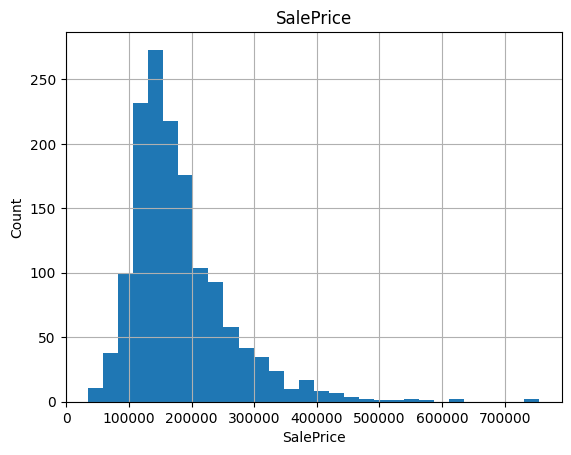

In [43]:
#目的変数のヒストグラム
df_train["SalePrice"].hist(bins=30)

plt.title("SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")

plt.show()

特徴量選択

In [44]:
#第1段階
# int・float型の列をすべて特徴量として選択（"Id"と"MSSubClass"目的変数SalePriceは除外）
features = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
features = [col for col in features
            if col not in ["Id", "SalePrice", "MSSubClass"]]

print(len(features))
print(features)

35
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


df_trainの数値型のヒストグラム

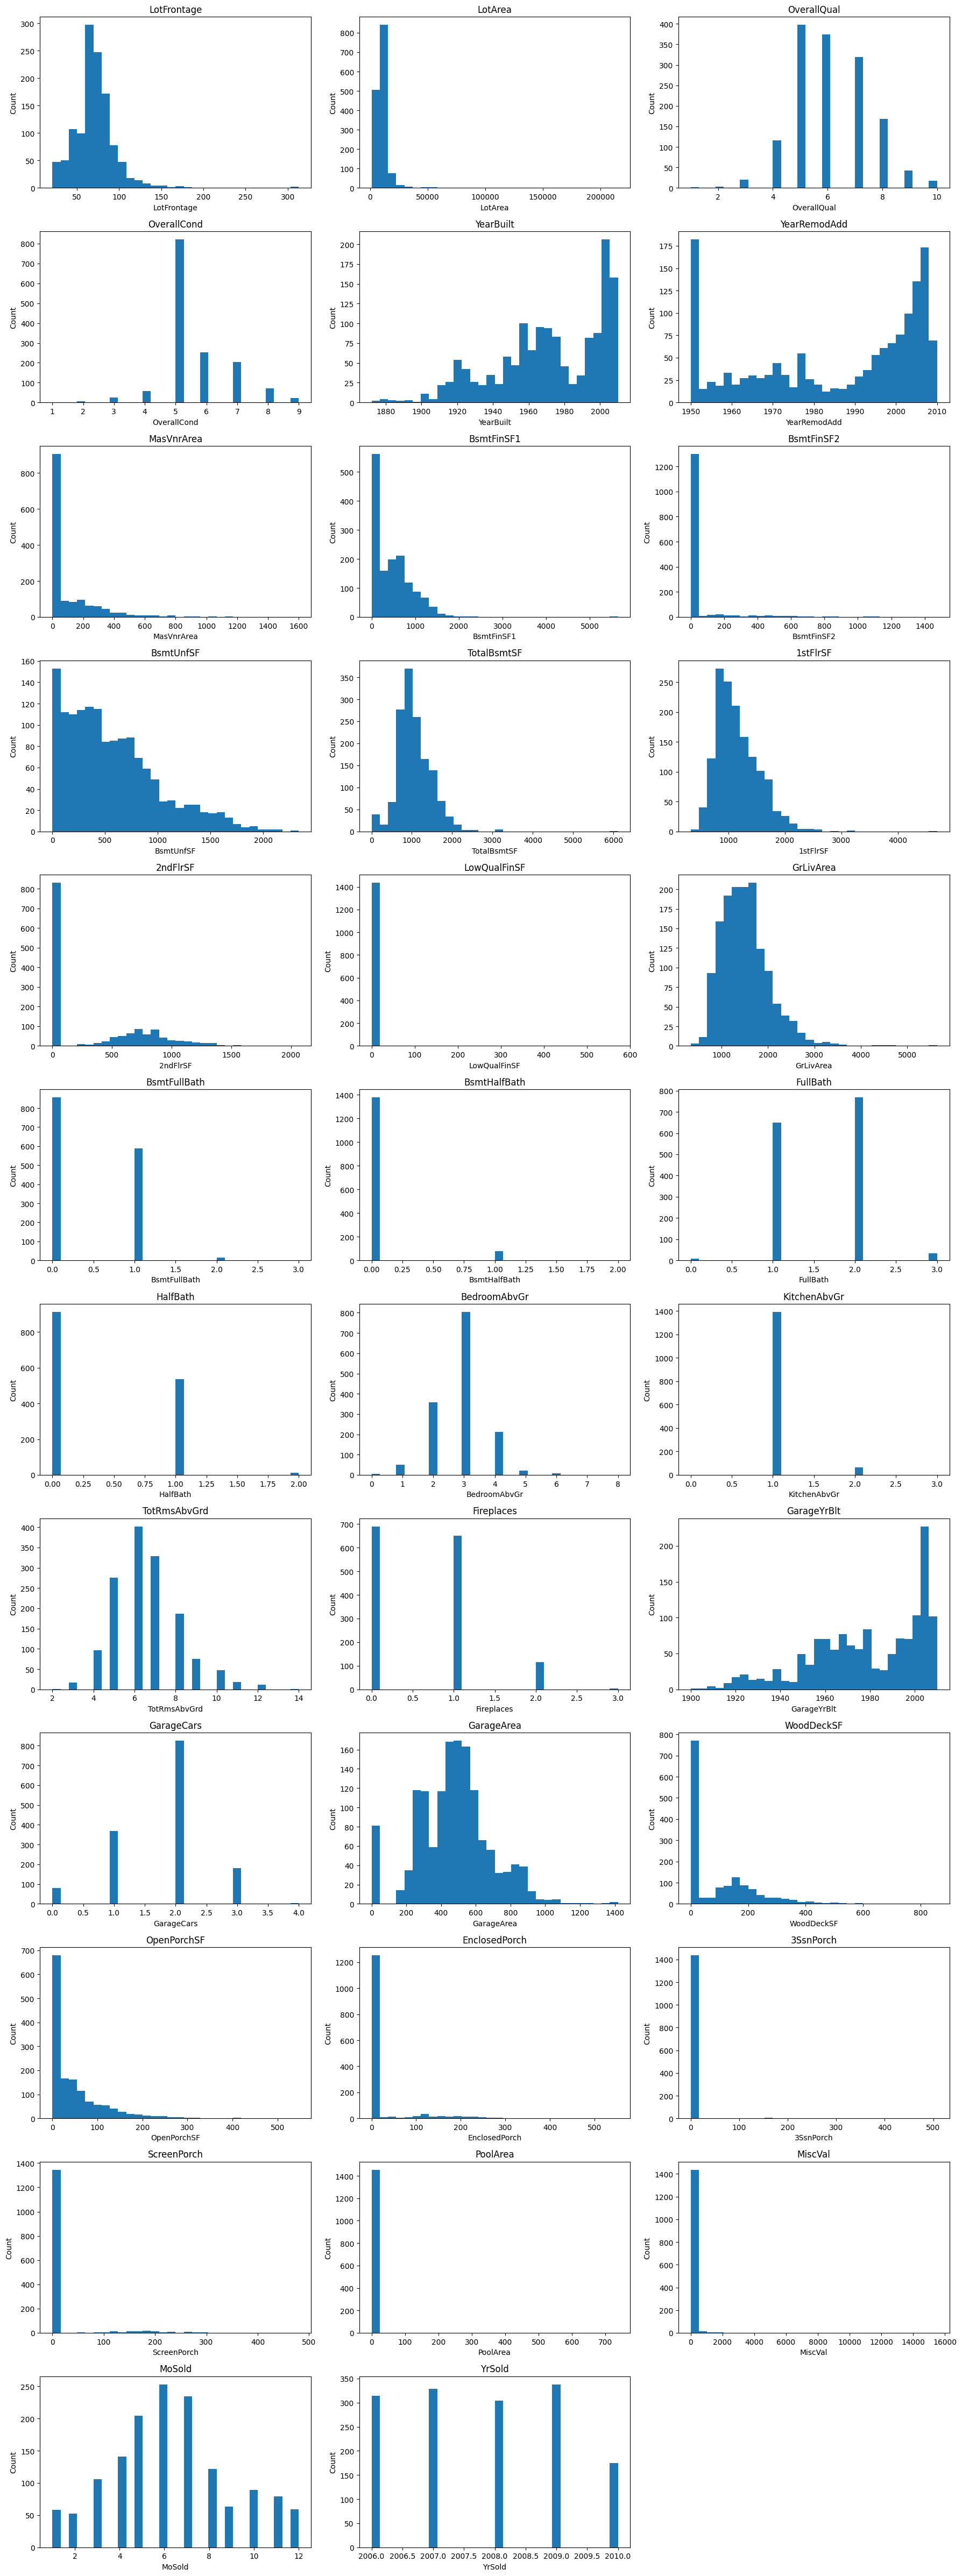

In [45]:
#グラフ作成
# 列数（1行に3枚グラフ表示）
n_cols = 3

# 必要な行数を計算
n_rows = math.ceil(len(features) / n_cols)

# subplot作成
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

# 2次元 → 1次元に変換
axes = axes.flatten()

# ヒストグラム作成
for i, col in enumerate(features):

    axes[i].hist(df_train[col], bins=30)

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# 余ったグラフを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# レイアウト調整
plt.tight_layout()

# 表示
plt.show()

In [46]:
# train.csv と test.csv を縦に結合して一括前処理
df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
print(df_all.shape)

(2919, 81)


In [47]:
df_all.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0


In [48]:
df_all.tail(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
2918,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


In [49]:
#欠損値
# ==============================
# House Prices 欠損値処理
# ==============================

# 1. Noneで埋める列
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
    df_all[col] = df_all[col].fillna('None')


# 2. 0で埋める列
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]

for col in zero_cols:
    df_all[col] = df_all[col].fillna(0)


# 3. 最頻値で埋める列
mode_cols = [
    'MSZoning',
    'Electrical',
    'KitchenQual',
    'Exterior1st',
    'Exterior2nd',
    'SaleType',
    'Functional'
]

for col in mode_cols:
    df_all[col] = df_all[col].fillna(df_all[col].mode()[0])


# 4. LotFrontageはNeighborhoodごとの中央値で埋める
df_all['LotFrontage'] = df_all.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)


# 5. Utilitiesは削除
#df_all = df_all.drop(columns=['Utilities'])


# 6. 欠損値確認
print(df_all.isnull().sum().sort_values(ascending=False).head(20))


SalePrice       1459
Utilities          2
Id                 0
LotFrontage        0
MSSubClass         0
Street             0
Alley              0
LotShape           0
MSZoning           0
LandContour        0
LotConfig          0
LandSlope          0
Neighborhood       0
Condition1         0
Condition2         0
BldgType           0
LotArea            0
HouseStyle         0
OverallQual        0
YearBuilt          0
dtype: int64


In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


特徴量エンジニアリング

In [51]:
### 面積 ###
# 総面積
df_all['TotalSF'] = df_all['TotalBsmtSF'] + df_all['1stFlrSF'] + df_all['2ndFlrSF']

# バスルーム合計面積
df_all['TotalBath'] = (df_all['FullBath'] + df_all['HalfBath'] * 0.5 + df_all['BsmtFullBath'] + df_all['BsmtHalfBath'] * 0.5)

# ポーチ合計面積
df_all['TotalPorchSF'] = (df_all['OpenPorchSF'] + df_all['EnclosedPorch'] + df_all['3SsnPorch'] + df_all['ScreenPorch'])

# 屋外面積
df_all['TotalOutdoorSF'] = df_all['TotalPorchSF'] + df_all['WoodDeckSF']

# 居住面積 / 敷地面積（土地利用率。高いほど「狭い土地に大きな家」）
df_all['LivLotRatio']  = df_all['GrLivArea'] / (df_all['LotArea'] + 1)#+1なのは、LotArea = 0の時の除算エラーを防ぐため


In [52]:
#features = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()# featuresを毎回最初から作り直すことで、セルの再実行でもエラーにならない
#features.remove("Id")
#features.remove("SalePrice")
print(len(features))


#新しい面積の特徴量をリストに追加
for f in ['TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF','LivLotRatio']:
   features.append(f)

#面積の元の特徴量を削除
#for f in ['FullBath','HalfBath','3SsnPorch','ScreenPorch','WoodDeckSF',]:#'GrLivArea','LotArea''2ndFlrSF','TotalBsmtSF',は残しておく
    #features.remove(f)

print(len(features))
print(features)


35
40
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio']


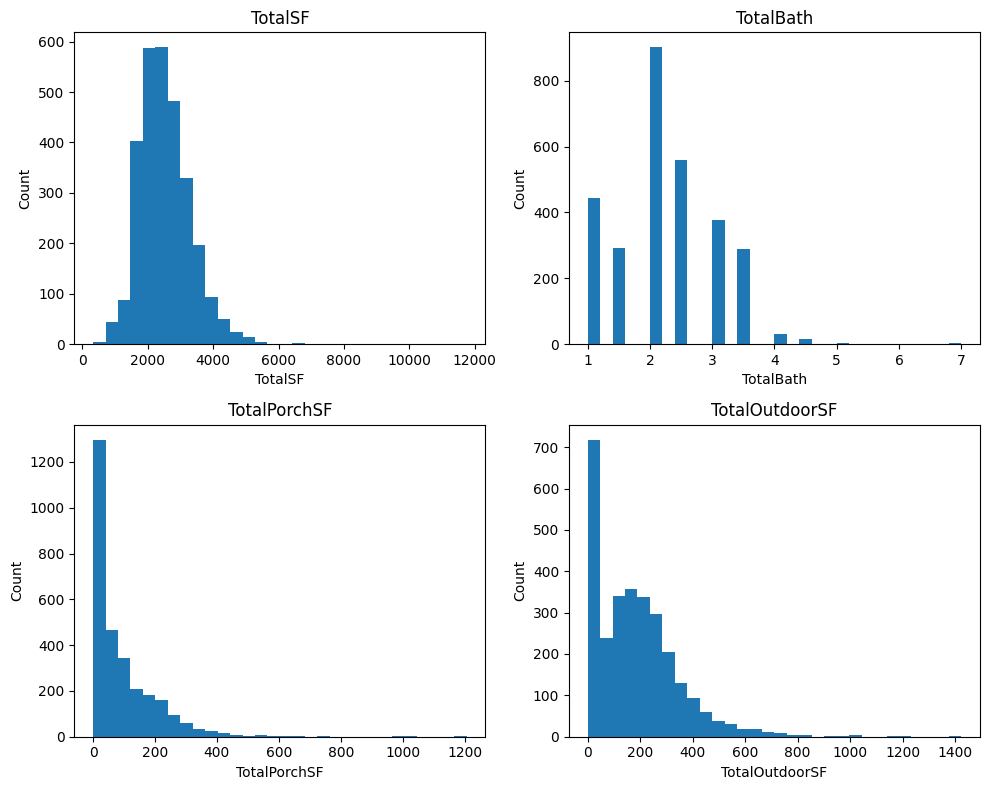

In [53]:
# ヒストグラム作成
area = ['TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for i, col in enumerate(area):

    axes[i].hist(df_all[col], bins=30)

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [54]:
###年齢系###
# 建築からの経過年数（古いほど価値が下がる傾向）
df_all['HouseAge']   = df_all['YrSold'] - df_all['YearBuilt']
# リフォームからの経過年数（リフォーム後に売られた家は価値が高い傾向）
df_all['RemodAge']   = df_all['YrSold'] - df_all['YearRemodAdd']
# ガレージ建築からの経過年数
df_all['GarageAge']  = df_all['YrSold'] - df_all['GarageYrBlt']
# リフォーム済みフラグ（建築年 ≠ リフォーム年）
df_all['IsRemodeled']= (df_all['YearBuilt'] != df_all['YearRemodAdd']).astype(int)
# 新築フラグ（売却年 == 建築年）
df_all['IsNew']      = (df_all['YrSold'] == df_all['YearBuilt']).astype(int)

In [55]:
#新しい年齢系の特徴量
for f in ['HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled','IsNew']:
    features.append(f)

#年齢系の元の特徴量を削除
#for f in ["YrSold","YearBuilt","YearRemodAdd"]:
    #features.remove(f)


print(len(features))

print(features)


45
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio', 'HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled', 'IsNew']


In [56]:
### 設備の有無 ###

# 設備の有無を 0/1 に変換（面積 0 = 設備なし）
df_all['HasBsmt']      = (df_all['TotalBsmtSF'] > 0).astype(int)#地下室
df_all['HasGarage']    = (df_all['GarageArea'] > 0).astype(int)
df_all['HasPool']      = (df_all['PoolArea'] > 0).astype(int)
df_all['HasFireplace'] = (df_all['Fireplaces'] > 0).astype(int)#暖炉
df_all['Has2ndFloor']  = (df_all['2ndFlrSF'] > 0).astype(int)
print(len(features))
print(features)
df_all.head(2)

45
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio', 'HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled', 'IsNew']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,HouseAge,RemodAge,GarageAge,IsRemodeled,IsNew,HasBsmt,HasGarage,HasPool,HasFireplace,Has2ndFloor
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,5,5,5.0,0,0,1,1,0,0,1
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,31,31,31.0,0,0,1,1,0,1,0


In [57]:
#新しい設備系の特徴量
for f in ['HasBsmt', 'HasGarage', 'HasPool', 'HasFireplace','Has2ndFloor']:
    features.append(f)
print(len(features))
#設備系の元の特徴量を削除
#for f in ['TotalBsmtSF','GarageArea','PoolArea','Fireplaces', '2ndFlrSF']:
    #features.remove(f)

print(len(features))

print(features)

50
50
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio', 'HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled', 'IsNew', 'HasBsmt', 'HasGarage', 'HasPool', 'HasFireplace', 'Has2ndFloor']


In [58]:
# --- 交互作用特徴量 ---
# 品質 × 面積: 「広くて高品質な家」を直接表現
df_all['QualSF']   = df_all['OverallQual'] * df_all['TotalSF']
df_all['QualGrLiv']= df_all['OverallQual'] * df_all['GrLivArea']

# 品質 × 築年数: 「高品質なのに古い家」と「低品質で新しい家」を区別
df_all['QualAge']  = df_all['OverallQual'] * df_all['HouseAge']

# 総合品質 + 総合状態（線形の加算でも有効な場合がある）
df_all['CondQual'] = df_all['OverallQual'] + df_all['OverallCond']

In [59]:
#品質 × 面積
for f in ['QualSF', 'QualGrLiv', 'QualAge', 'CondQual']:
    features.append(f)

#質 × 面積の元の特徴量を削除
#for f in ['OverallQual','GrLivArea','HouseAge','OverallCond']:
    #features.remove(f)


print(len(features))

print(features)

54
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio', 'HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled', 'IsNew', 'HasBsmt', 'HasGarage', 'HasPool', 'HasFireplace', 'Has2ndFloor', 'QualSF', 'QualGrLiv', 'QualAge', 'CondQual']


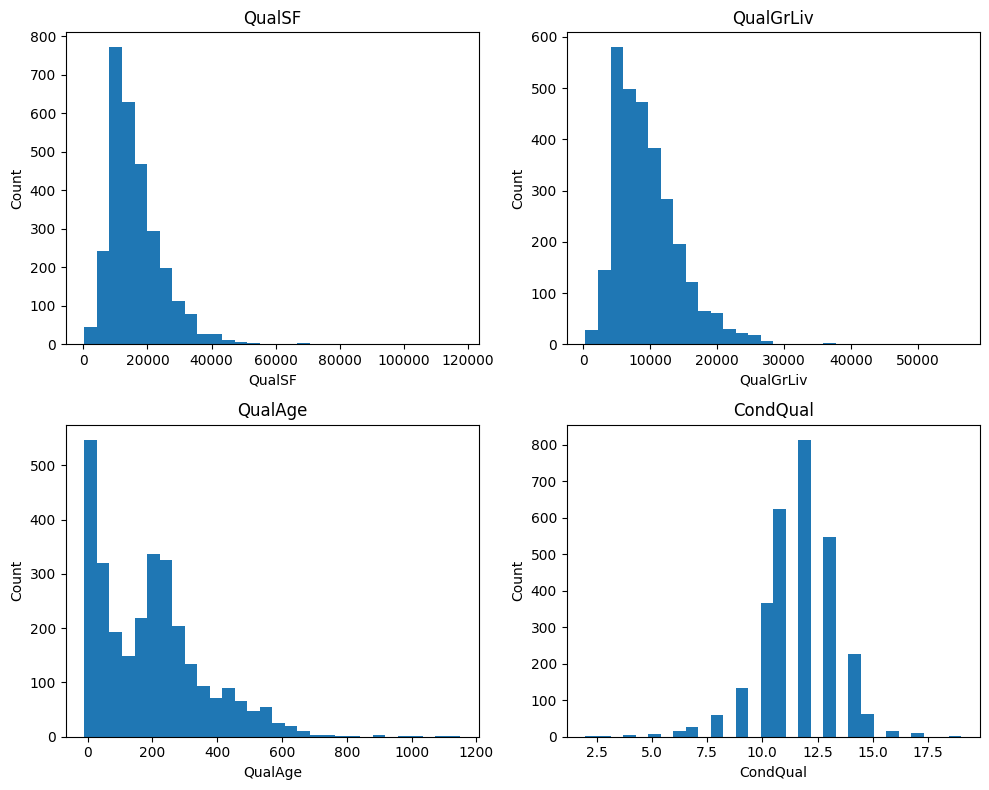

In [60]:
# ヒストグラム作成
area =  ['QualSF', 'QualGrLiv', 'QualAge', 'CondQual']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for i, col in enumerate(area):

    axes[i].hist(df_all[col], bins=30)

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [67]:
### カテゴリ###
features_str  = df_train.select_dtypes(include=["object"]).columns.tolist() + ["MSSubClass"]
features_str  = [col for col in features_str if col != 'Utilities']
print(len(features_str))
print(features_str)

43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'MSSubClass']


In [62]:
# ===== 順序エンコーディング（品質・状態系カラム） =====
# Ex > Gd > TA > Fa > Po > None の序列を数値に変換
# → LightGBM は数値の大小関係を学習できるため、
#    one-hot より順序エンコーディングが有効なケースが多い

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
            'HeatingQC', 'KitchenQual', 'FireplaceQu',
            'GarageQual', 'GarageCond', 'PoolQC']:
    df_all[col] = df_all[col].map(quality_map)

# 地下室の露出度: Gd（全面露出）> Av > Mn > No > None
df_all['BsmtExposure'] = df_all['BsmtExposure'].map(
    {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})

# 地下室仕上げ品質
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
df_all['BsmtFinType1'] = df_all['BsmtFinType1'].map(bsmt_fin_map)
df_all['BsmtFinType2'] = df_all['BsmtFinType2'].map(bsmt_fin_map)

# ガレージ仕上げ
df_all['GarageFinish'] = df_all['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})

# 機能性: Typ（標準）> Min1/2 > Mod > Maj1/2 > Sev > Sal（救済）
df_all['Functional'] = df_all['Functional'].map(
    {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0})

# その他の二値・順序カラム
df_all['LandSlope']  = df_all['LandSlope'].map({'Sev': 3, 'Mod': 2, 'Gtl': 1})
df_all['Street']     = df_all['Street'].map({'Pave': 1, 'Grvl': 0})
df_all['Alley']      = df_all['Alley'].map({'Pave': 2, 'Grvl': 1, 'None': 0})
df_all['PavedDrive'] = df_all['PavedDrive'].map({'Y': 2, 'P': 1, 'N': 0})
df_all['CentralAir'] = df_all['CentralAir'].map({'Y': 1, 'N': 0})
df_all['LotShape']   = df_all['LotShape'].map({'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0})

print('ordinal encoding 完了')#カテゴリを「順番付きの数値」に変換する方法

ordinal encoding 完了


In [63]:
# 順序エンコーディングされていない残りの文字列型列をカテゴリ型に変換
# LightGBMはcategory型をネイティブに処理できる
str_cols = df_all.select_dtypes(include=['object']).columns.tolist()
for col in str_cols:
    df_all[col] = df_all[col].astype('category')
print(f'カテゴリ型に変換: {str_cols}')

カテゴリ型に変換: ['MSZoning', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [64]:
# df_allのtrain部分（SalePriceがある行）からX_train/y_trainを作成
features_all = features + features_str

print(features_all)

X_train = df_all[df_all['SalePrice'].notna()] [features_all].reset_index(drop=True)
# y_train = np.log1p(df_all[df_all['SalePrice'].notna()] ['SalePrice'].reset_index(drop=True))
y_train = np.log1p(df_train[df_train['SalePrice'].notna()] ['SalePrice'].reset_index(drop=True))

print(X_train.shape)
print(y_train.shape)

['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'TotalOutdoorSF', 'LivLotRatio', 'HouseAge', 'RemodAge', 'GarageAge', 'IsRemodeled', 'IsNew', 'HasBsmt', 'HasGarage', 'HasPool', 'HasFireplace', 'Has2ndFloor', 'QualSF', 'QualGrLiv', 'QualAge', 'CondQual', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'Bsm

In [65]:
###対数変換（右歪み分布の正規化）###
# featuresに含まれる歪み大の面積系のみ log1p で正規化
log_base_cols = ['1stFlrSF','TotalBsmtSF','LotArea', 'LotFrontage', 'TotalBath', 'TotalSF','QualSF', 'QualGrLiv']
# 元の特徴量をfeaturesから除外
features = [col for col in features if col not in log_base_cols]
print(len(features))
# log1p で正規化した特徴量を作成、featuresに追加(log_が付く)
for col in log_base_cols:
    df_all[f'log_{col}'] = np.log1p(df_all[col])
    features.append(f'log_{col}')

# # SalePrice も対数変換
# df_all['SalePrice'] =
# y_train = np.log1p(df_all['SalePrice'])
# print(y_train)

# log特徴量を反映した features_all と X_train を再作成
features_all = features + features_str

X_train = df_all[df_all['SalePrice'].notna()][features_all].reset_index(drop=True)
print(f"log変換後: features={len(features)}, features_all={len(features_all)}")
print("X_train:", X_train.shape)

46
log変換後: features=54, features_all=97
X_train: (1460, 97)


モデル作成

In [70]:
!pip install optuna
!pip install --upgrade xgboost

import optuna
import xgboost as xgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# =========================
# 1. 学習用データを分ける
# =========================

X = X_train.copy()
y = y_train.copy()

X_tr, X_valid, y_tr, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================
# 2. Optunaの目的関数
# =========================

def objective(trial):

    params = {
        # 回帰問題用
        "objective": "reg:squarederror",
        "eval_metric": "rmse",

        # Optunaで調整するパラメータ
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0),

        # 固定パラメータ
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0
    }

    # モデル作成
    model = xgb.XGBRegressor(**params, enable_categorical=True)

    # 学習
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    # 予測
    pred = model.predict(X_valid)

    # RMSEを計算
    rmse = np.sqrt(mean_squared_error(y_valid, pred))

    return rmse


# =========================
# 3. Optunaで探索
# =========================

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50)


# =========================
# 4. 結果確認
# =========================

print("Best RMSE:", study.best_value)
print("Best params:")
print(study.best_params)


# =========================
# 5. 最良パラメータで再学習
# =========================

best_params = study.best_params

best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 0
})

best_model = xgb.XGBRegressor(**best_params, enable_categorical=True)

best_model.fit(X_train, y_train)


# =========================
# 6. テストデータを予測
# =========================

# df_allのtest部分（SalePriceがNaN）からX_testを取得
X_test = df_all[df_all['SalePrice'].isna()][features_all].reset_index(drop=True)

pred_log = best_model.predict(X_test)

# 目的変数を log1p していた場合は元に戻す
pred = np.expm1(pred_log)

[I 2026-05-29 10:15:27,259] A new study created in memory with name: no-name-b87f1621-43b1-4bdc-9210-f30fb7ae5f77
[I 2026-05-29 10:15:32,297] Trial 0 finished with value: 0.1379523891929871 and parameters: {'n_estimators': 1938, 'learning_rate': 0.03296421126355094, 'max_depth': 7, 'min_child_weight': 1, 'subsample': 0.7490432308622789, 'colsample_bytree': 0.6614564663201659, 'reg_alpha': 2.444267827694646, 'reg_lambda': 1.811393436933932}. Best is trial 0 with value: 0.1379523891929871.
[I 2026-05-29 10:15:39,699] Trial 1 finished with value: 0.13520535053996613 and parameters: {'n_estimators': 1064, 'learning_rate': 0.031096590576041076, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.9183930076402634, 'colsample_bytree': 0.6782119463419779, 'reg_alpha': 1.7548085143491687, 'reg_lambda': 7.148684284302718}. Best is trial 1 with value: 0.13520535053996613.
[I 2026-05-29 10:15:41,082] Trial 2 finished with value: 0.17048052559543309 and parameters: {'n_estimators': 724, 'learning

Best RMSE: 0.13011849648051124
Best params:
{'n_estimators': 746, 'learning_rate': 0.07588519649787119, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.8812078944751213, 'colsample_bytree': 0.7663477262637867, 'reg_alpha': 0.594536040277132, 'reg_lambda': 2.6411822263719427}


In [71]:
#分割数（KFoldの分割数）を設定
n_splits = 5

#KFoldを作成（データを）ランダムにシャッフル指定５分割
cv = KFold(n_splits=n_splits, shuffle=True, random_state=123)

#評価結果を格納するリスト
metrics = []

#特徴量重要度を格納するDataFrame
imp = pd.DataFrame()

In [72]:
# #クロスバリエーション（CV）
# for nfold, (train_idx, val_idx) in enumerate(cv.split(X_train)):
#     #インデックスを使って学習用とデータと検証用データに分割
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

#     print("train:", X_tr.shape, y_tr.shape)
#     print("val:", X_va.shape, y_va.shape)

#     #LightGBM回帰モデルを作成
#     model = lgb.LGBMRegressor(**params)

#     #モデル学習(early stopping付き)
#     model.fit(
#         X_tr,
#         y_tr,
#         #学習中に評価するデータ（trainとvalidation）
#         eval_set=[(X_tr, y_tr), (X_va, y_va)],
#         callbacks=[
#             #検証データで性能が改善しなければ学習を止める
#             lgb.early_stopping(stopping_rounds=100, verbose=True),

#             #ログ出力を抑制（0にすると詳細ログ非表示）
#             lgb.log_evaluation(0)
#          ],
#     )
#     #学習データで予測
#     y_tr_pred = model.predict(X_tr)
#     #検証データで予測
#     y_va_pred = model.predict(X_va)
#     #学習データのRMSEを計算
#     rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
#     #検証データのRMSEを計算
#     rmse_va = np.sqrt(mean_squared_error(y_va, y_va_pred))
#     #RMSEを表示
#     print("[RMSE]tr: {:.2f}, va: {:.2f}".format(rmse_tr, rmse_va))
#     #foldごとの結果を保存（fold番号、train RMSE、val RMSE）

#     metrics.append([nfold, rmse_tr, rmse_va])

#     _imp = pd.DataFrame({
#         "col": X_train.columns,
#         "imp": model.feature_importances_,
#         'nfold': nfold
#         })

#     imp = pd.concat([imp, _imp], axis=0, ignore_index=True)

In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # 前処理済みの X_train を使って学習用・検証用に分割
# # ※ df_train の生データ（str型カラムあり）は XGBoost に渡せないため、
# #    前のセルで df_all から作成済みの X_train を使う
# X_tr, X_valid, y_tr, y_valid = train_test_split(
#     X_train, y_train,
#     test_size=0.2,
#     random_state=42
# )

# # モデル作成
# # enable_categorical=True: category型カラムを XGBoost がネイティブに処理できるようにする
# model = XGBRegressor(
#     n_estimators=500,       # 決定木の本数（多いほど学習精度↑、過学習に注意）
#     learning_rate=0.05,     # 学習率（小さいほど慎重に学習、過学習しにくい）
#     max_depth=3,            # 各決定木の深さ（深いほど複雑なパターンを学習、過学習リスク↑）
#     subsample=0.8,          # 各木を学習する際に使う行のサンプリング割合（過学習抑制）
#     colsample_bytree=0.8,   # 各木を学習する際に使う特徴量のサンプリング割合（過学習抑制）
#     random_state=42,        # 乱数シード（再現性確保）
#     enable_categorical=True # category型カラムをネイティブに処理（数値変換不要）
# )

# # 学習
# model.fit(X_tr, y_tr)

# # 予測
# pred = model.predict(X_valid)

# # RMSE
# rmse = np.sqrt(mean_squared_error(y_valid, pred))
# print("RMSE:", rmse)


In [ ]:
# # metricsリストをNumPy配列に変換（行: fold, 列: [fold番号, train RMSE, val RMSE]）
# # LightGBM CV がコメントアウト中のため、空の場合はスキップ
# if len(metrics) > 0:
#     metrics_arr = np.array(metrics)
#     print(metrics_arr)
#     print("[cv ] tr: {:.2f}+-{:.2f}, va: {:.2f}+-{:.2f}".format(
#         metrics_arr[:,1].mean(), metrics_arr[:,1].std(),
#         metrics_arr[:,2].mean(), metrics_arr[:,2].std(),
#     ))
# else:
#     print("LightGBM CV はコメントアウト中のためスキップ")


In [81]:
# XGBoost の特徴量重要度（上位80件）
imp_df = pd.Series(
    best_model.feature_importances_,
    index=X_tr.columns
).sort_values(ascending=False)

imp_df.head(80)


,0
log_QualSF,0.253087
OverallQual,0.107278
CentralAir,0.080867
HasFireplace,0.056069
log_TotalSF,0.046740
...,...
IsRemodeled,0.000528
Electrical,0.000506
BsmtFinSF2,0.000472
BsmtCond,0.000416


In [ ]:
# df_allのtest部分（SalePriceがNaN）からX_testを取得
#X_test = df_all[df_all['SalePrice'].isna()][features_all].reset_index(drop=True)

#X_test.shape

In [75]:
# テストデータで売却価格を予測
# ※ y_train は log1p 変換済みのため、predict の出力も log スケール
# → expm1 で元のドルスケールに逆変換してから提出する
# y_test_pred = np.expm1(model.predict(X_test))

# Kaggle 提出用 DataFrame を作成（必須フォーマット: Id + SalePrice）
df_submit = pd.DataFrame({
    'Id': df_test.Id,         # テストデータの物件 ID
    'SalePrice': pred  # 予測した売却価格（ドル単位に戻した値）
})
df_submit

,Id,SalePrice
0,1461,120437.953125
1,1462,156111.625000
2,1463,184970.562500
3,1464,198765.375000
4,1465,182934.171875
...,...,...
1454,2915,83856.882812
1455,2916,80318.671875
1456,2917,167697.406250
1457,2918,120505.515625


In [77]:
df_submit.to_csv("/content/drive/MyDrive/house/hp-submission_260529_XGBR_optuna.csv", index=False)